In [9]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd, solve, norm
from scipy.interpolate import UnivariateSpline


np.set_printoptions(precision=6, suppress=True)


def compute_target_function_values(x_values: np.ndarray) -> np.ndarray:
    """Вычисляет значения целевой функции."""
    return np.sin(2.0 * np.pi * x_values) + 0.5 * np.cos(4.0 * np.pi * x_values)


random_generator = np.random.default_rng(42)

point_count = 30
noise_standard_deviation = 0.35


fine_grid = np.linspace(0.0, 1.0, 500)

data_nodes = np.sort(random_generator.uniform(0.0, 1.0, point_count))
exact_values_at_nodes = compute_target_function_values(data_nodes)
noisy_values_at_nodes = (
    exact_values_at_nodes
    + noise_standard_deviation * random_generator.standard_normal(point_count)
)

exact_values_on_fine_grid = compute_target_function_values(fine_grid)

## 1. Интерполяция полиномом

In [10]:
def build_vandermonde_matrix(
    x_values: np.ndarray,
    polynomial_degree: int,
) -> np.ndarray:
    """Строит матрицу Вандермонда для заданных узлов и степени полинома."""
    return np.vander(x_values, N=polynomial_degree + 1, increasing=True)


def compute_polynomial_interpolation(
    interpolation_nodes: np.ndarray,
    node_values: np.ndarray,
    evaluation_points: np.ndarray,
) -> np.ndarray:
    """Вычисляет значения интерполяционного полинома в заданных точках."""
    polynomial_degree = len(interpolation_nodes) - 1
    vandermonde_matrix_at_nodes = build_vandermonde_matrix(
        interpolation_nodes,
        polynomial_degree,
    )
    polynomial_coefficients = solve(vandermonde_matrix_at_nodes, node_values)
    vandermonde_matrix_at_eval = build_vandermonde_matrix(
        evaluation_points,
        polynomial_degree,
    )
    return vandermonde_matrix_at_eval @ polynomial_coefficients

## 2. Регуляризация Тихонова

In [11]:
def compute_tikhonov_regression_via_svd(
    interpolation_nodes: np.ndarray,
    node_values: np.ndarray,
    polynomial_degree: int,
    regularization_parameter: float,
    evaluation_points: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Вычисляет регрессию Тихонова через SVD-разложение матрицы Вандермонда."""
    vandermonde_matrix_at_nodes = build_vandermonde_matrix(
        interpolation_nodes,
        polynomial_degree,
    )
    left_singular_vectors, singular_values, right_singular_vectors_transposed = svd(
        vandermonde_matrix_at_nodes,
        full_matrices=False,
    )
    tikhonov_filter = singular_values / (singular_values**2 + regularization_parameter)
    polynomial_coefficients = right_singular_vectors_transposed.T @ (
        tikhonov_filter * (left_singular_vectors.T @ node_values)
    )
    vandermonde_matrix_at_eval = build_vandermonde_matrix(
        evaluation_points,
        polynomial_degree,
    )
    regression_values = vandermonde_matrix_at_eval @ polynomial_coefficients
    return regression_values, polynomial_coefficients, singular_values


def compute_gcv_scores(
    interpolation_nodes: np.ndarray,
    node_values: np.ndarray,
    polynomial_degree: int,
    regularization_parameter_array: np.ndarray,
) -> np.ndarray:
    """Вычисляет критерий обобщенной перекрестной проверки (GCV) для набора параметров."""
    vandermonde_matrix_at_nodes = build_vandermonde_matrix(
        interpolation_nodes,
        polynomial_degree,
    )
    left_singular_vectors, singular_values, _ = svd(
        vandermonde_matrix_at_nodes,
        full_matrices=False,
    )
    observation_count = len(node_values)
    projected_values = left_singular_vectors.T @ node_values
    gcv_score_list = []
    for regularization_parameter in regularization_parameter_array:
        filter_factors = singular_values**2 / (
            singular_values**2 + regularization_parameter
        )
        residual_norm_squared = (
            norm(
                node_values
                - left_singular_vectors @ (filter_factors * projected_values)
            )
            ** 2
            / observation_count
        )
        effective_degrees_of_freedom = 1.0 - np.sum(filter_factors) / observation_count
        gcv_score_list.append(
            residual_norm_squared / max(effective_degrees_of_freedom**2, 1e-15)
        )
    return np.array(gcv_score_list, dtype=float)

## 3. Визуализация результатов

Сравним работу различных методов на зашумленной выборке.

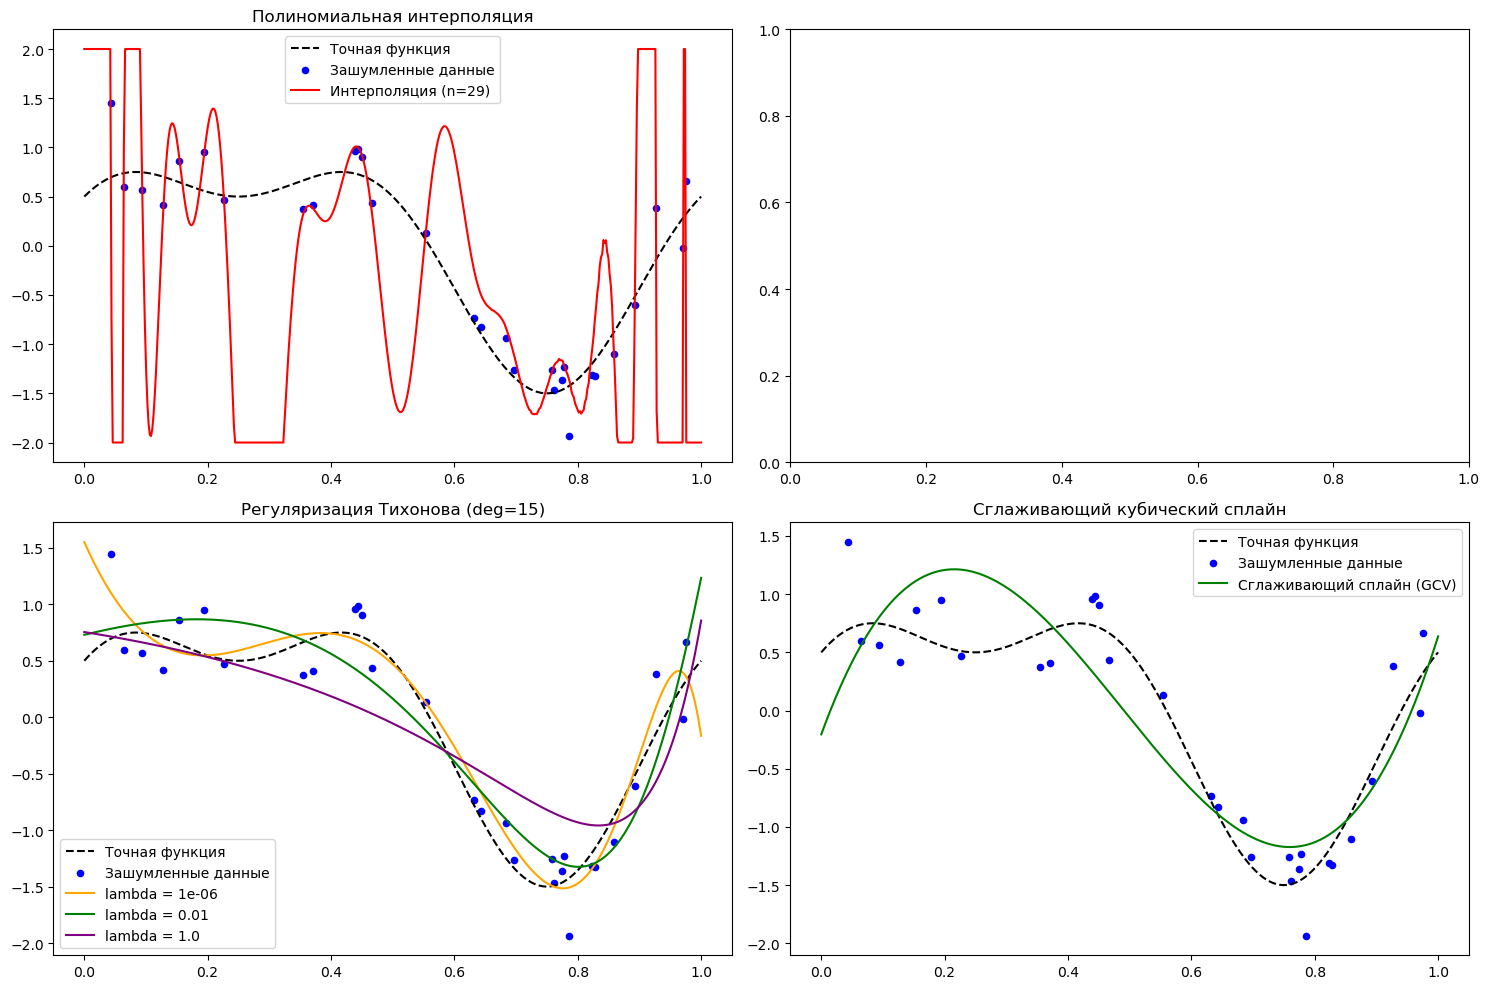

In [12]:
interpolated_values = np.clip(
    compute_polynomial_interpolation(data_nodes, noisy_values_at_nodes, fine_grid),
    -2.0,
    2.0,
)

tikhonov_regularization_parameters = [1e-6, 1e-2, 1.0]
tikhonov_colors = ["orange", "green", "purple"]
tikhonov_degree = 15

smoothing_spline = UnivariateSpline(data_nodes, noisy_values_at_nodes, k=3, s=None)

figure, axes = plt.subplots(2, 2, figsize=(15, 10))

interpolation_axis = axes[0, 0]
interpolation_axis.plot(
    fine_grid,
    exact_values_on_fine_grid,
    color="black",
    linestyle="--",
    label="Точная функция",
)
interpolation_axis.scatter(
    data_nodes,
    noisy_values_at_nodes,
    color="blue",
    s=20,
    label="Зашумленные данные",
)
interpolation_axis.plot(
    fine_grid,
    interpolated_values,
    color="red",
    label="Интерполяция (n=29)",
)
interpolation_axis.set_title("Полиномиальная интерполяция")
interpolation_axis.legend()

tikhonov_axis = axes[1, 0]
tikhonov_axis.plot(
    fine_grid,
    exact_values_on_fine_grid,
    color="black",
    linestyle="--",
    label="Точная функция",
)
tikhonov_axis.scatter(
    data_nodes,
    noisy_values_at_nodes,
    color="blue",
    s=20,
    label="Зашумленные данные",
)
for regularization_parameter, line_color in zip(
    tikhonov_regularization_parameters,
    tikhonov_colors,
):
    tikhonov_values, _, _ = compute_tikhonov_regression_via_svd(
        data_nodes,
        noisy_values_at_nodes,
        tikhonov_degree,
        regularization_parameter,
        fine_grid,
    )
    tikhonov_axis.plot(
        fine_grid,
        tikhonov_values,
        color=line_color,
        label=f"lambda = {regularization_parameter}",
    )
tikhonov_axis.set_title(f"Регуляризация Тихонова (deg={tikhonov_degree})")
tikhonov_axis.legend()

spline_axis = axes[1, 1]
spline_axis.plot(
    fine_grid,
    exact_values_on_fine_grid,
    color="black",
    linestyle="--",
    label="Точная функция",
)
spline_axis.scatter(
    data_nodes,
    noisy_values_at_nodes,
    color="blue",
    s=20,
    label="Зашумленные данные",
)
spline_axis.plot(
    fine_grid,
    smoothing_spline(fine_grid),
    color="green",
    label="Сглаживающий сплайн (GCV)",
)
spline_axis.set_title("Cглаживающий кубический сплайн")
spline_axis.legend()

figure.tight_layout()
plt.show()